# **Projet AARN : Deep Learning for Crop Classification Using Multi-Source Satellite Data**
----------------------------------------------
# **Project Content :**
## **Part 2: Base Classification Model**
- Dataset Acquisition + Preprocessing :
  - Google Earth Engine (check ressources)
- Data Exploration:
  - visualization of time-series
  - vegetation indices,
  - class distribution analysis,
  - temporal patterns of different crops,
  - inspection of missing values or noise.
- Model Implementation

### Resources :
- **Dataset Acquisition + Preprocessing :** https://code.earthengine.google.com/?accept_repo=users/faizmaps/aarn-project
- **Cropland Data Layer classnames :** https://www.nass.usda.gov/Research_and_Science/Cropland/sarsfaqs2.php



In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
import os
data_path = os.path.join("drive", "MyDrive", "AARN_Projet", "AdditionalData")

Mounted at /content/drive


# **Data Loading**

## Description over how Cropland Data Layer file works
The CDL csv file contains two things
- Bands taken from sentinel data, 36*10 in total, these are the areas of the crops that will have the label
-  The actual cropland label, each number means some type of crop

In [ ]:
import os
import pandas as pd

cal1 = pd.read_csv(os.path.join(data_path, "california/region1/crops_CDL_CaliforniaRegion1.csv"))

# nouveaux
ark1 = pd.read_csv(os.path.join(data_path, "arkansas/region1/crops_CDL_ArkansasRegion1.csv"))
ark2 = pd.read_csv(os.path.join(data_path, "arkansas/region2/crops_CDL_ArkansasRegion2.csv"))
cal2 = pd.read_csv(os.path.join(data_path, "california/region2/crops_CDL_CaliforniaRegion2.csv"))



# nettoyage colonnes inutiles
def clean(df):
    return df.drop(columns=['.geo', 'system:index'], errors='ignore')

cal1 = clean(cal1)
ark1 = clean(ark1)
ark2 = clean(ark2)
cal2 = clean(cal2)

# ajouter colonne région
cal1['region'] = 'california1'
cal2['region'] = 'california2'
ark1['region'] = 'arkansas1'
ark2['region'] = 'arkansas2'

# fusion
dataset = pd.concat([cal1, ark1, ark2, cal2], ignore_index=True)

print(dataset.shape)
dataset.head()

(16381, 362)


,0_B11,0_B12,0_B2,0_B3,0_B4,0_B5,0_B6,0_B7,0_B8,0_B8A,...,9_B2,9_B3,9_B4,9_B5,9_B6,9_B7,9_B8,9_B8A,cropland,region
0,0.2174,0.1754,0.0446,0.0526,0.0712,0.0861,0.1122,0.1247,0.1502,0.1514,...,0.04830,0.07935,0.09520,0.12490,0.20420,0.22890,0.2480,0.24875,72,california1
1,0.2371,0.2155,0.0426,0.0512,0.0696,0.0866,0.0913,0.1085,0.1202,0.1306,...,0.06450,0.08805,0.10680,0.14150,0.20065,0.21780,0.2378,0.24690,69,california1
2,0.2176,0.1655,0.0582,0.0700,0.0920,0.1263,0.1517,0.1721,0.1824,0.2025,...,0.05375,0.07860,0.09935,0.13720,0.18125,0.19655,0.2122,0.21885,71,california1
3,0.2439,0.2090,0.0522,0.0637,0.0780,0.1377,0.1420,0.1610,0.1570,0.1704,...,0.04855,0.07910,0.08895,0.16230,0.22490,0.25080,0.2700,0.26330,121,california1
4,0.1817,0.1397,0.0391,0.0526,0.0679,0.0957,0.1224,0.1407,0.1622,0.1659,...,0.04570,0.07110,0.08980,0.12605,0.17075,0.18405,0.2061,0.20685,71,california1


# **Data Exploration:**
skip the code after this one if u need to train asap

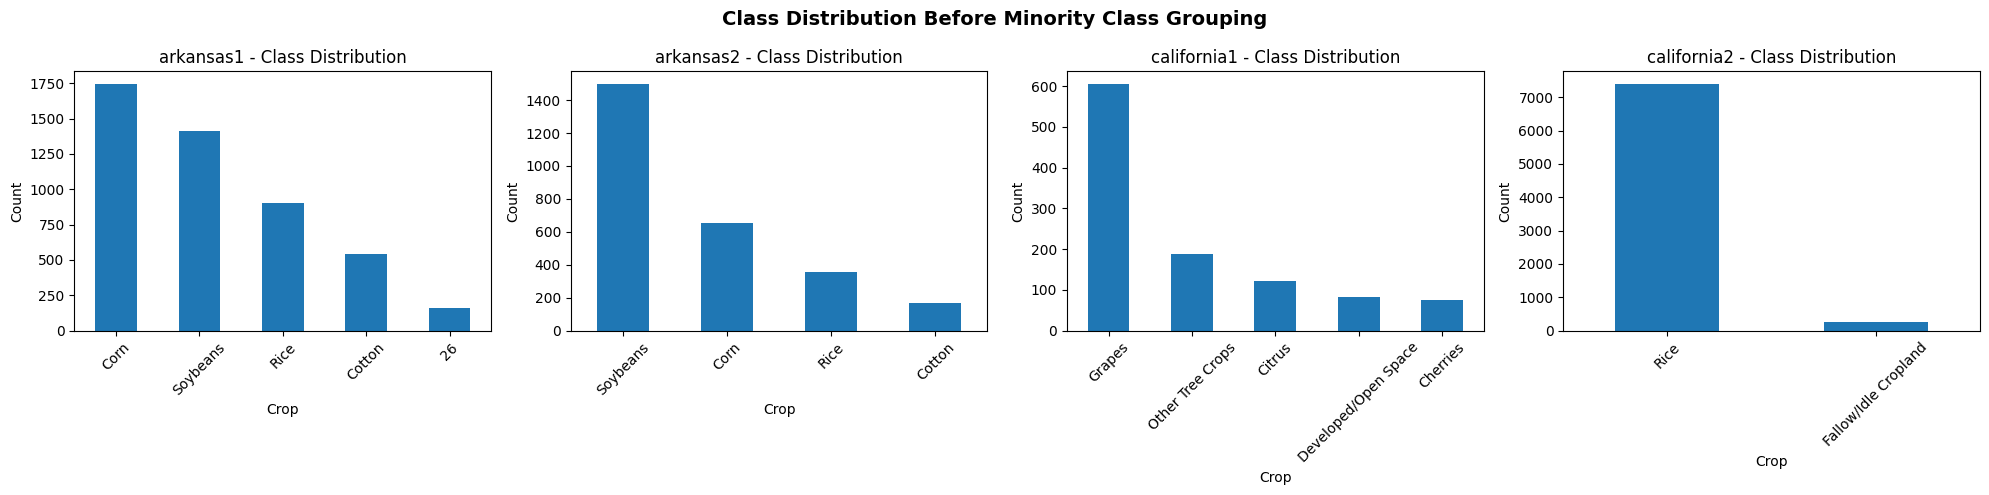

In [ ]:
# class names
CLASS_NAMES = {
    1: "Corn",
    2: "Cotton",
    3: "Rice",
    5: "Soybeans",
    61: "Fallow/Idle Cropland",
    66: "Cherries",
    69: "Grapes",
    71: "Other Tree Crops",
    72: "Citrus",
    74: "Alfalfa",
    75: "Almonds",
    121: "Developed/Open Space",
    204: "Pistachios",
    999: "Others",
}

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (region, grp) in zip(axes, dataset.groupby('region')):
    counts = grp['cropland'].value_counts().rename(index=CLASS_NAMES)
    counts = counts[counts > 50]  # ignores smaller classes
    counts.plot(kind='bar', ax=ax, colormap='tab10')
    ax.set_title(f'{region} - Class Distribution')
    ax.set_xlabel('Crop'); ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
fig.suptitle("Class Distribution Before Minority Class Grouping", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3955/1727657719.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3955/1727657719.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


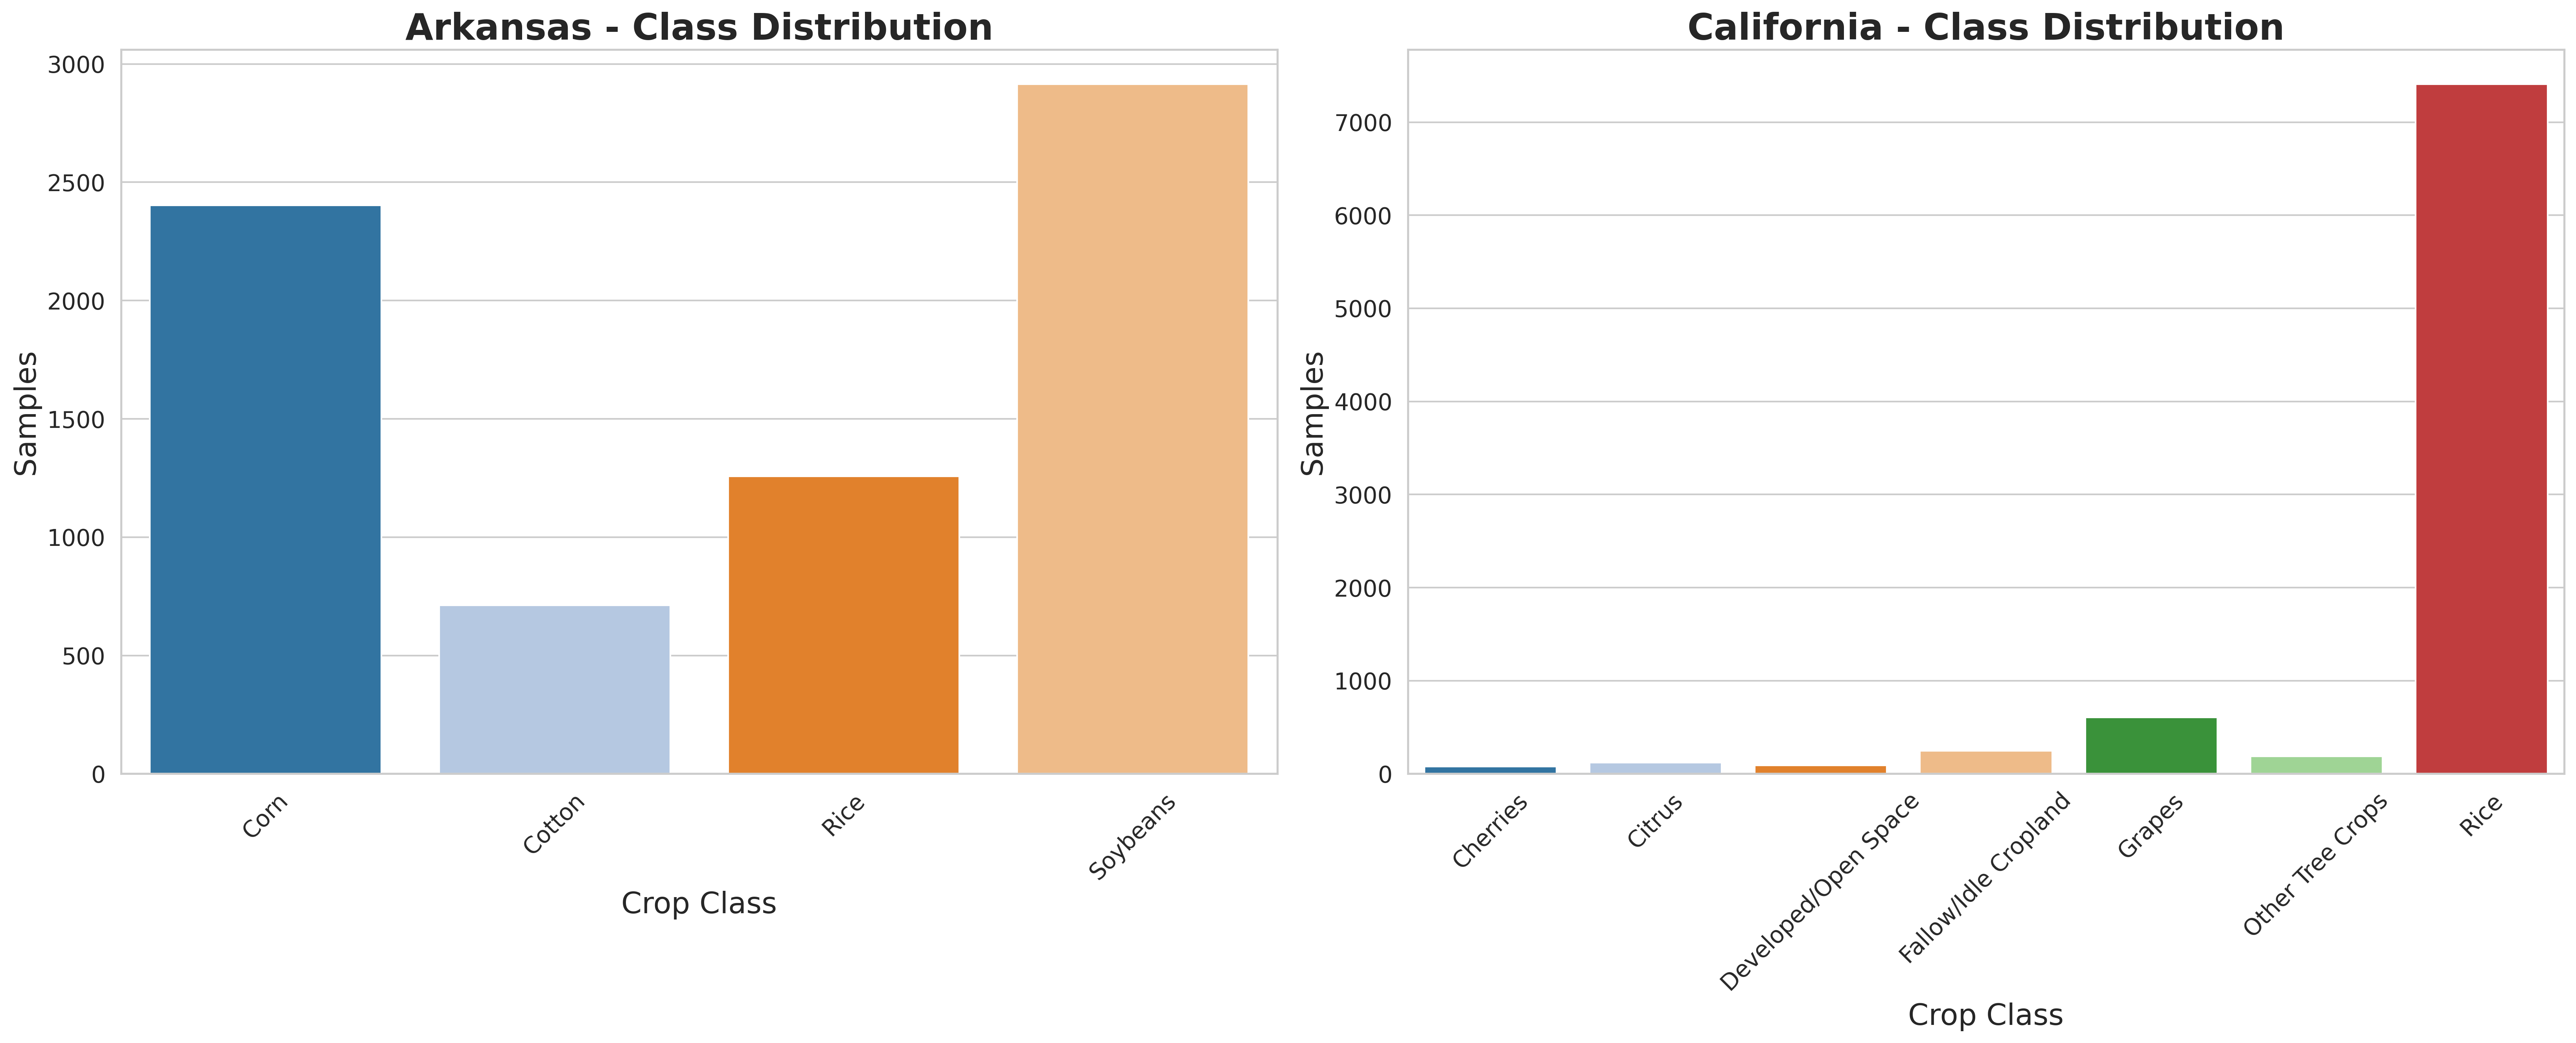

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# merge regions
dataset['region_group'] = dataset['region'].replace({
    'arkansas1': 'Arkansas',
    'arkansas2': 'Arkansas',
    'california1': 'California',
    'california2': 'California'
})

dataset['class_name'] = dataset['cropland'].map(CLASS_NAMES)

filtered = dataset.groupby(['region_group', 'class_name']).size().reset_index(name='count')
filtered = filtered[filtered['count'] > 50]

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(22, 9), dpi=300)

for ax, region in zip(axes, ['Arkansas', 'California']):
    data = filtered[filtered['region_group'] == region]

    sns.barplot(
        data=data,
        x='class_name',
        y='count',
        ax=ax,
        palette='tab20'
    )

    ax.set_title(f'{region} - Class Distribution', fontsize=22, fontweight='bold')
    ax.set_xlabel("Crop Class", fontsize=18)
    ax.set_ylabel("Samples", fontsize=18)

    ax.tick_params(axis='x', labelrotation=45, labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.savefig("class_distribution_seaborn.png", dpi=300, bbox_inches='tight')
plt.show()

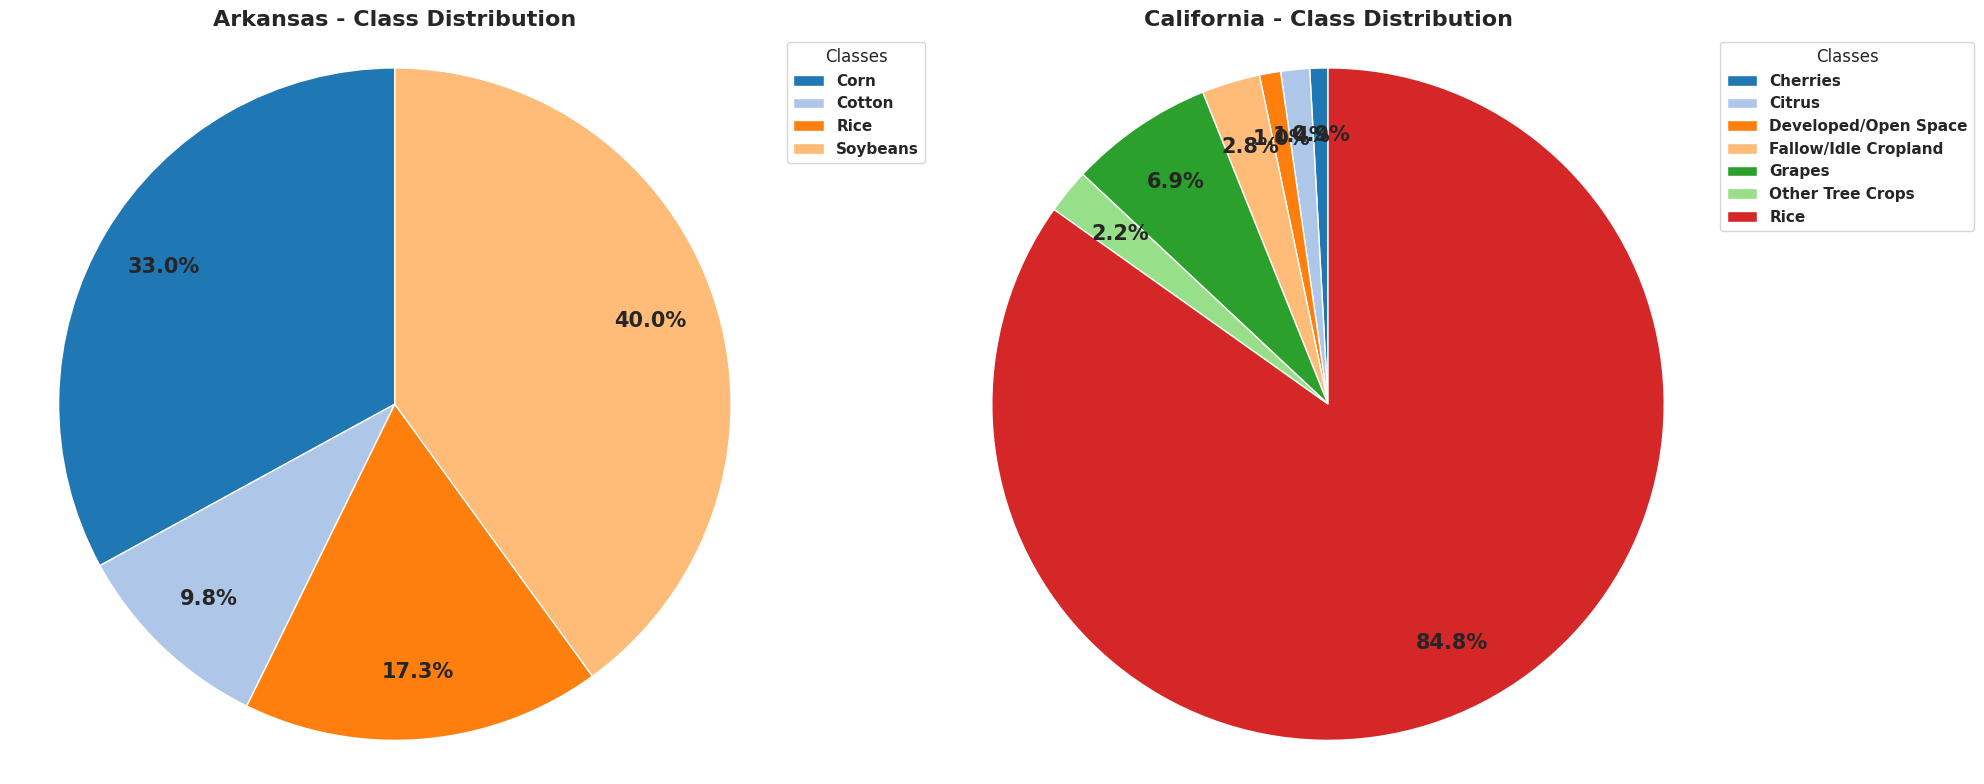

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, region in zip(axes, ['Arkansas', 'California']):
    data = filtered[filtered['region_group'] == region]
    colors = sns.color_palette('tab20', n_colors=len(data))

    wedges, texts, autotexts = ax.pie(
        data['count'],
        labels=None,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        pctdistance=0.8
    )

    for autotext in autotexts:
        autotext.set_fontsize(15)
        autotext.set_fontweight('bold')

    ax.legend(
        wedges,
        data['class_name'],
        title="Classes",
        loc="upper left",
        bbox_to_anchor=(1, 1),
        prop={'weight': 'bold'}
    )

    ax.set_title(f'{region} - Class Distribution', fontsize=16, fontweight='bold')
    ax.axis('equal')

plt.tight_layout()
plt.savefig("class_dist_pie.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
time_steps = sorted(set(c.split('_')[0] for c in dataset.columns if '_B' in c), key=lambda x: int(x))

for t in time_steps:
    nir = dataset[f'{t}_B8']
    red = dataset[f'{t}_B4']
    dataset[f'NDVI_{t}'] = (nir - red) / (nir + red)

ndvi_cols = [f'NDVI_{t}' for t in time_steps]
print(time_steps)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35']


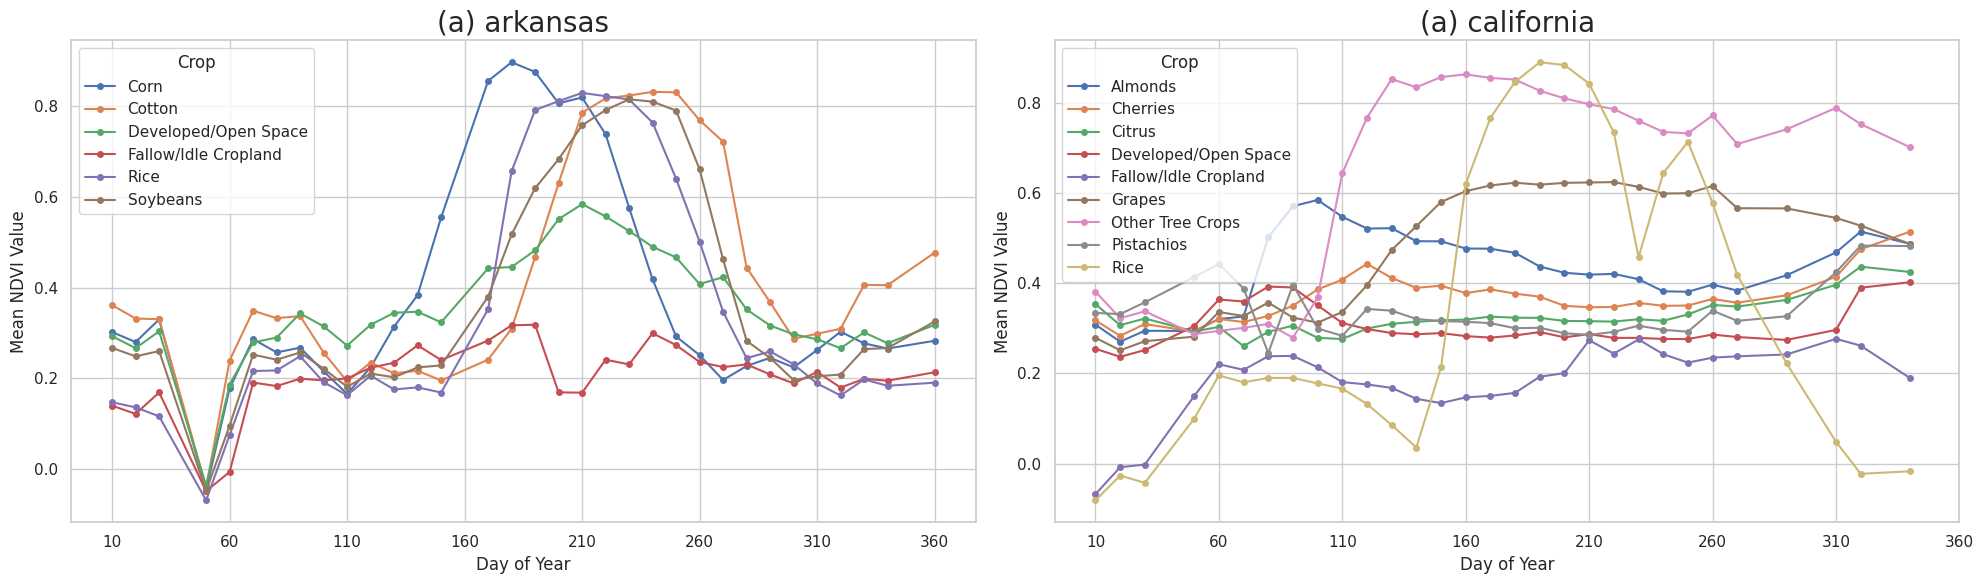

In [ ]:
dataset['state'] = dataset['region'].str.extract(r'(california|arkansas)')
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, (state, grp) in zip(axes, dataset.groupby('state')):
    ndvi_mean = grp.copy()
    ndvi_mean['crop_name'] = ndvi_mean['cropland'].map(CLASS_NAMES)
    ndvi_mean = ndvi_mean.groupby('crop_name')[ndvi_cols].mean().T
    ndvi_mean.index = [(int(i.split('_')[1]) + 1) * 10 for i in ndvi_mean.index]

    ndvi_mean.dropna(axis=1, how='all', inplace=True)
    ndvi_mean.dropna(axis=0, how='any', inplace=True)

    ndvi_mean.plot(ax=ax, marker='o', markersize=4)
    ax.set_title(f'(a) {state}', fontsize=20)
    ax.set_xlabel('Day of Year'); ax.set_ylabel('Mean NDVI Value')
    ax.set_xticks(range(10, 361, 50))
    ax.legend(title='Crop'); ax.grid(True)

plt.tight_layout()
plt.savefig("ndvi-timeseries.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# inspection of missing values or noise :
band_cols = [c for c in dataset.columns if '_B' in c and 'NDVI' not in c]
missing_pct = dataset[band_cols].isnull().mean() * 100

print("Total missing values/noise:", dataset[band_cols].isnull().sum().sum())

Total missing values/noise: 0


In [ ]:
# drop all data exploration colms
dataset = dataset.drop(columns=['state'])
dataset.drop(columns=[col for col in dataset.columns if 'NDVI' in col or col in ['crop_name', 'state']], inplace=True)

# **Data Cleaning :**
Article says : "Specifically, crop types that constitute less than 5 % of the total number of samples were merged into a category labeled as “others”."

That means any type of crop with tiny population will get into its own class called "other", aka that crop doesn't matter. they did 5%, in our data it must be 2% (to include cotton + grapes)

Source for class names : http://nass.usda.gov/Research_and_Science/Cropland/sarsfaqs2.php

In [ ]:
# merge small classes into others
threshold = 0.02 * len(dataset)
class_counts = dataset['cropland'].value_counts()

small_classes = class_counts[class_counts < threshold].index

dataset['cropland'] = dataset['cropland'].apply(
    lambda x: 999 if x in small_classes else x
)

# Match cdl's codes with them classnaems
named_counts = dataset['cropland'].value_counts().rename(index=CLASS_NAMES)
print(named_counts)


# supprimer 5000 samples de la classe 3 pour l'equilibre
class_3 = dataset[dataset['cropland'] == 3]
to_remove = class_3.sample(n=5000, random_state=42)
dataset = dataset.drop(to_remove.index)


named_counts = dataset['cropland'].value_counts().rename(index=CLASS_NAMES)
print(named_counts)

cropland
Rice        8667
Soybeans    2915
Corn        2403
Others      1078
Cotton       712
Grapes       606
Name: count, dtype: int64
cropland
Rice        3667
Soybeans    2915
Corn        2403
Others      1078
Cotton       712
Grapes       606
Name: count, dtype: int64


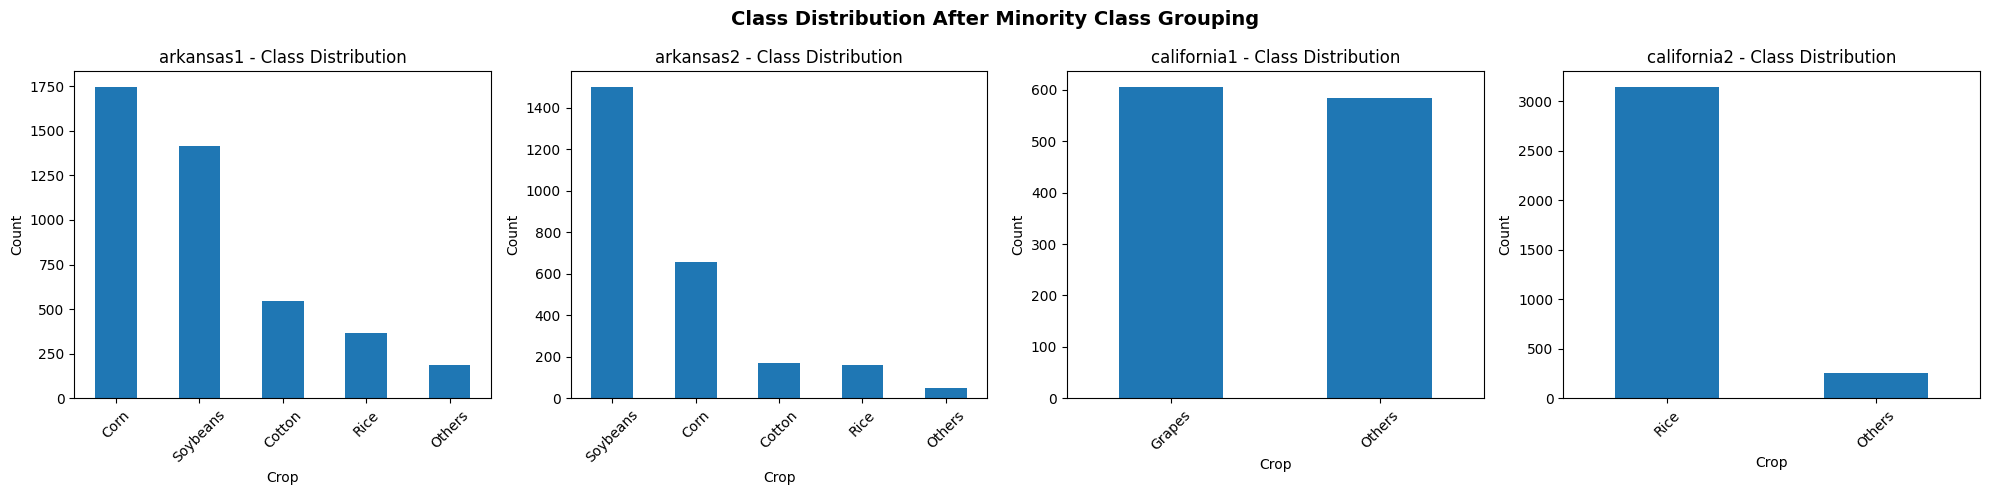

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (state, grp) in zip(axes, dataset.groupby('region')):
    counts = grp['cropland'].value_counts().rename(index=CLASS_NAMES)
    counts.plot(kind='bar', ax=ax, colormap='tab10')
    ax.set_title(f'{state} - Class Distribution')
    ax.set_xlabel('Crop'); ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
fig.suptitle("Class Distribution After Minority Class Grouping", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3955/1727657719.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3955/1727657719.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


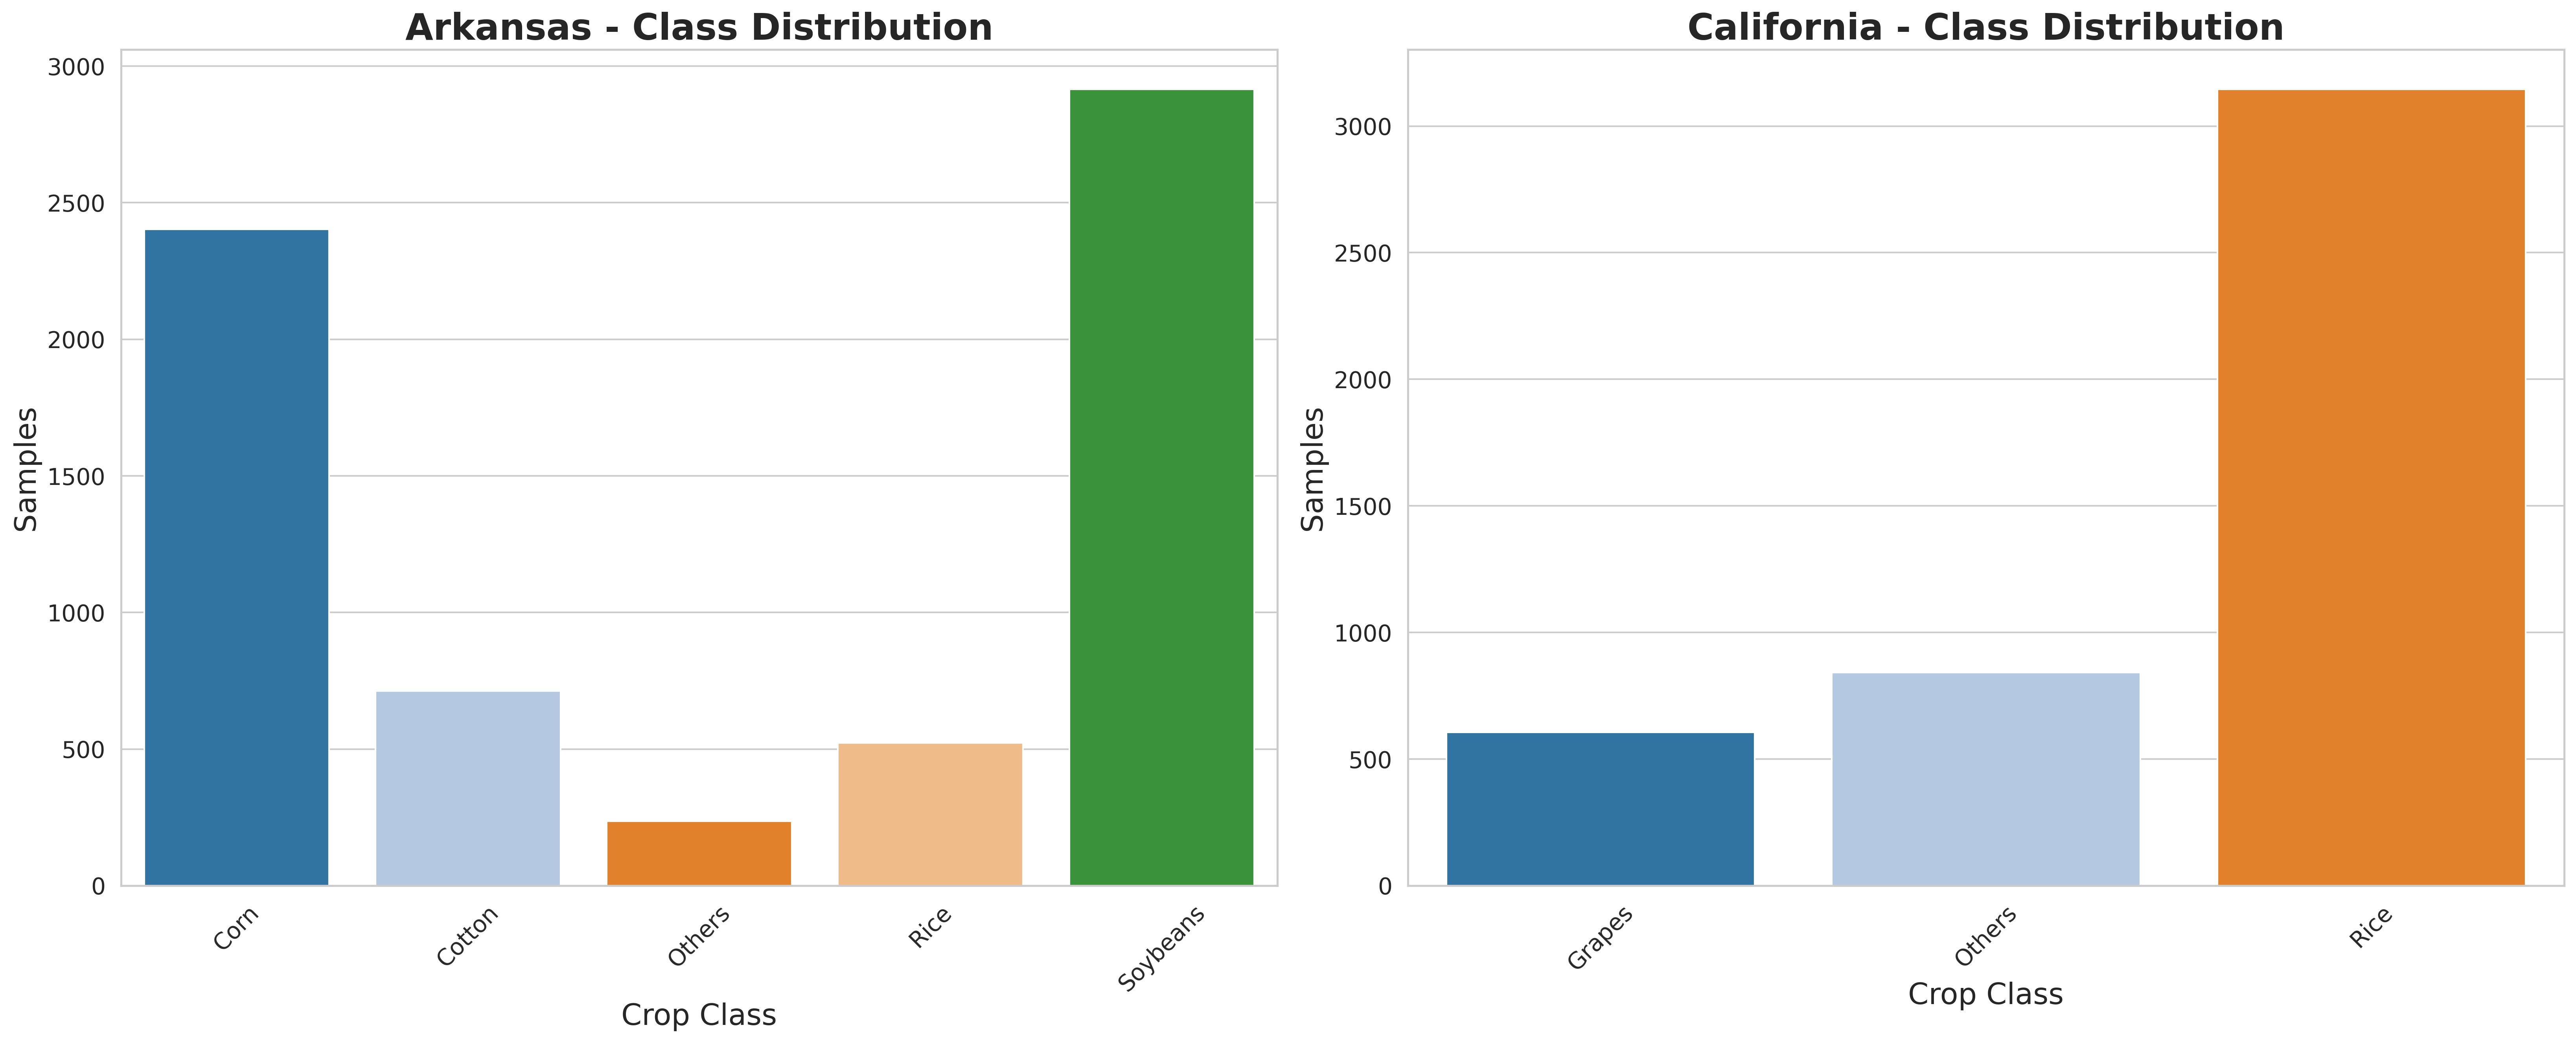

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# merge regions
dataset['region_group'] = dataset['region'].replace({
    'arkansas1': 'Arkansas',
    'arkansas2': 'Arkansas',
    'california1': 'California',
    'california2': 'California'
})

dataset['class_name'] = dataset['cropland'].map(CLASS_NAMES)

filtered = dataset.groupby(['region_group', 'class_name']).size().reset_index(name='count')
filtered = filtered[filtered['count'] > 50]

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(22, 9), dpi=300)

for ax, region in zip(axes, ['Arkansas', 'California']):
    data = filtered[filtered['region_group'] == region]

    sns.barplot(
        data=data,
        x='class_name',
        y='count',
        ax=ax,
        palette='tab20'
    )

    ax.set_title(f'{region} - Class Distribution', fontsize=22, fontweight='bold')
    ax.set_xlabel("Crop Class", fontsize=18)
    ax.set_ylabel("Samples", fontsize=18)

    ax.tick_params(axis='x', labelrotation=45, labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.savefig("class_distribution_seaborn.png", dpi=300, bbox_inches='tight')
plt.show()

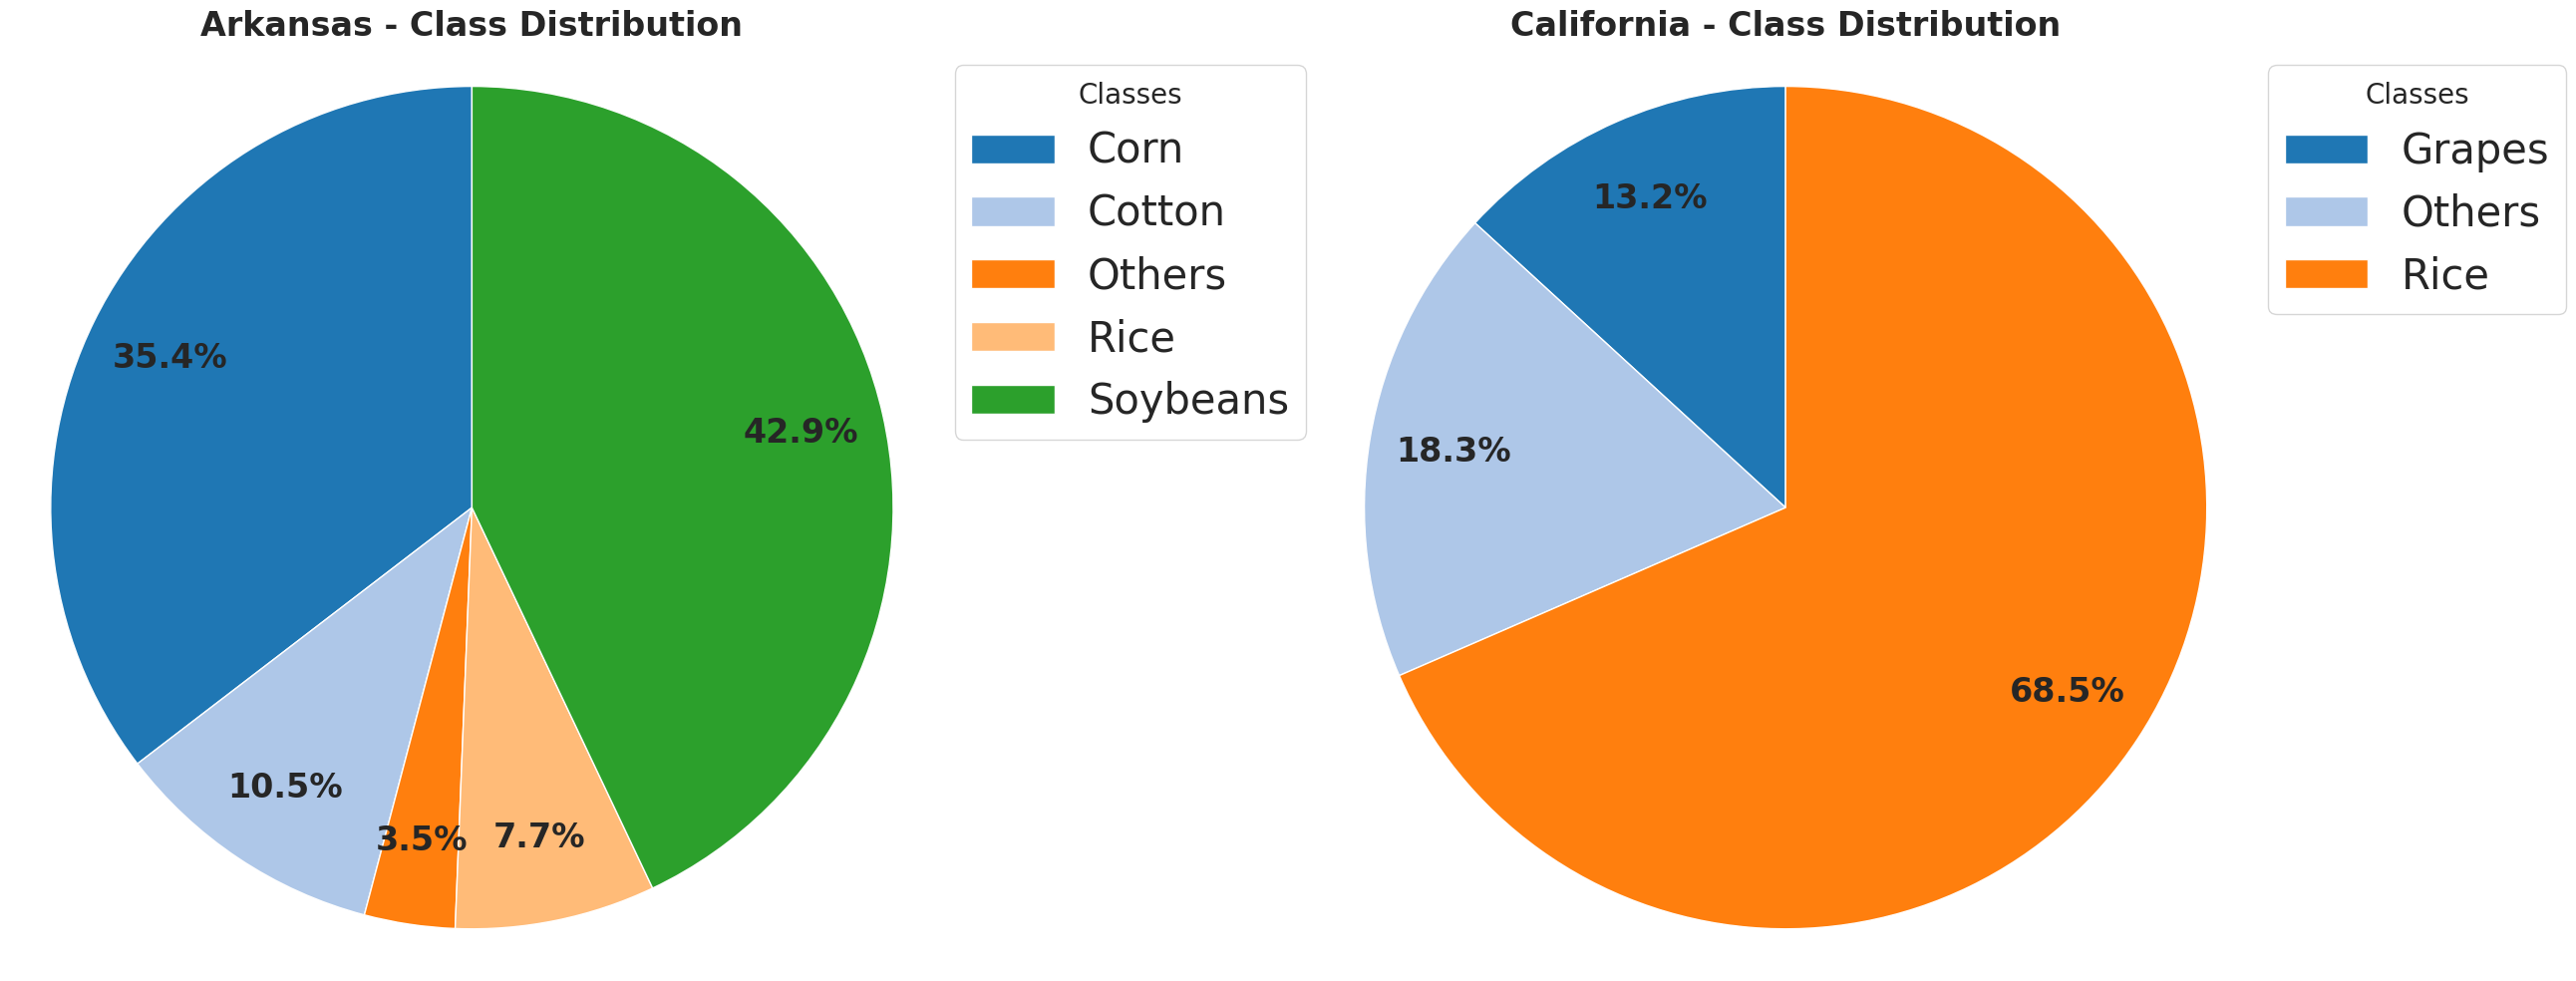

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(26, 10))

for ax, region in zip(axes, ['Arkansas', 'California']):
    data = filtered[filtered['region_group'] == region]
    colors = sns.color_palette('tab20', n_colors=len(data))

    wedges, texts, autotexts = ax.pie(
        data['count'],
        labels=None,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        pctdistance=0.8
    )

    for autotext in autotexts:
        autotext.set_fontsize(24)
        autotext.set_fontweight('bold')

    ax.legend(
        wedges,
        data['class_name'],
        title="Classes",
        title_fontsize=20,
        loc="upper left",
        bbox_to_anchor=(1, 1),
        prop={'size': 30}
    )

    ax.set_title(f'{region} - Class Distribution', fontsize=24, fontweight='bold')
    ax.axis('equal')

plt.tight_layout()
plt.savefig("class_dist_pie.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print(dataset['region'].value_counts())

region
arkansas1      4257
california2    3402
arkansas2      2531
california1    1191
Name: count, dtype: int64


- X = données (features)
- y = labels (types de cultures)

In [ ]:
X = dataset.drop(columns=['cropland', 'region']).values
y = dataset['cropland'].values

print(X.shape)

# data gets reshaped to 36, 10 (timeseries)
X = X.reshape(len(X), 36, 10)
print("X shape:", X.shape)

# classes become encoded intoa vector of 1 and 0s
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

num_classes = len(label_encoder.classes_)
print("Classes:", num_classes)

(11381, 360)
X shape: (11381, 36, 10)
Classes: 6


# **Data Splitting**
Article took small samples of train and validation, and leave the rest for testing.

In [ ]:
from sklearn.model_selection import train_test_split

def split_data(df, n_train=240, n_val=60):
    train_list, val_list, test_list = [], [], []
    for cls, group in df.groupby('cropland'):
        group = group.sample(frac=1, random_state=42).reset_index(drop=True)
        train_list.append(group.iloc[:n_train])
        val_list.append(group.iloc[n_train:n_train + n_val])
        test_list.append(group.iloc[n_train + n_val:])
    return pd.concat(train_list), pd.concat(val_list), pd.concat(test_list)

ark = dataset[dataset['region'].isin(['arkansas1', 'arkansas2'])]
cal = dataset[dataset['region'].isin(['california1', 'california2'])]

ark_train, ark_val, ark_test = split_data(ark)
cal_train, cal_val, cal_test = split_data(cal)

train_df = pd.concat([ark_train, cal_train])
val_df   = pd.concat([ark_val,   cal_val])
test_df  = pd.concat([ark_test,  cal_test])

feature_cols = [c for c in dataset.columns if '_B' in c]

X_train = train_df[feature_cols].values.reshape(-1, 36, 10)
X_val   = val_df[feature_cols].values.reshape(-1, 36, 10)
X_test  = test_df[feature_cols].values.reshape(-1, 36, 10)

y_train = label_encoder.fit_transform(train_df['cropland'].values)
y_val   = label_encoder.transform(val_df['cropland'].values)
y_test  = label_encoder.transform(test_df['cropland'].values)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (1916, 36, 10)
Val:   (420, 36, 10)
Test:  (9045, 36, 10)


# **MCTNet Implementation**

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# 1. ECA (Efficient Channel Attention)
class ECA(keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.avg_pool = keras.layers.GlobalAveragePooling1D()
        self.conv     = keras.layers.Conv1D(1, kernel_size=1, padding='same', use_bias=False)
        self.sigmoid  = keras.layers.Activation('sigmoid')

    def call(self, x):
        gap    = self.avg_pool(x)
        gap    = tf.expand_dims(gap, axis=1)
        weight = self.sigmoid(self.conv(gap))
        return x * weight


# 2. ALPE (Attention-based Learnable Positional Encoding)
class ALPE(keras.layers.Layer):
    def __init__(self, d_model, max_len=36, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.max_len = max_len

    def build(self, input_shape):
        self.conv = keras.layers.Conv1D(
            self.d_model, kernel_size=3, padding='same', use_bias=False
        )
        self.eca  = ECA()

    def call(self, x, mask):
        # sinusoidal positional encoding
        positions = np.arange(self.max_len)[:, np.newaxis]
        dims      = np.arange(self.d_model)[np.newaxis, :]
        pe        = np.where(
            dims % 2 == 0,
            np.sin(positions / (10000 ** (dims / self.d_model))),
            np.cos(positions / (10000 ** ((dims - 1) / self.d_model)))
        ).astype(np.float32)
        pe = tf.constant(pe)
        pe = tf.expand_dims(pe, 0)
        pe = tf.tile(pe, [tf.shape(x)[0], 1, 1])

        # mask out missing positions
        mask_expanded = tf.cast(
            tf.expand_dims(mask, -1), tf.float32
        )
        pe = pe * mask_expanded

        # conv + ECA
        pe = self.conv(pe)
        pe = self.eca(pe)
        return pe


# 3. CNN Sub-module
class CNNSubModule(keras.layers.Layer):
    def __init__(self, filters, kernel_size=3, **kwargs):
        super().__init__(**kwargs)
        self.filters     = filters
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv1 = keras.layers.Conv1D(
            self.filters, self.kernel_size, padding='same', use_bias=False
        )
        self.bn1   = keras.layers.BatchNormalization()
        self.conv2 = keras.layers.Conv1D(
            self.filters, self.kernel_size, padding='same', use_bias=False
        )
        self.bn2   = keras.layers.BatchNormalization()
        self.relu  = keras.layers.ReLU()

    def call(self, x, training=False):
        out = self.relu(self.bn1(self.conv1(x), training=training))
        out = self.bn2(self.conv2(out), training=training)
        return self.relu(out + x)

class CTFusion(keras.layers.Layer):
    def __init__(self, d_model, n_head, use_alpe=False, max_len=36, **kwargs):
        super().__init__(**kwargs)
        self.d_model  = d_model
        self.n_head   = n_head
        self.use_alpe = use_alpe
        self.max_len  = max_len

    def build(self, input_shape):
        self.cnn         = CNNSubModule(self.d_model)
        self.transformer = TransformerSubModule(
            self.d_model, self.n_head, self.use_alpe, self.max_len
        )
        self.pool        = keras.layers.MaxPooling1D(pool_size=2)

    def call(self, x, alpe_mask=None, training=False):
        cnn_out   = self.cnn(x, training=training)
        trans_out = self.transformer(x, alpe_mask=alpe_mask, training=training)
        fused     = tf.concat([cnn_out, trans_out], axis=-1)
        fused     = self.pool(fused)
        return fused


class TransformerSubModule(keras.layers.Layer):
    def __init__(self, d_model, n_head, use_alpe=False, max_len=36, **kwargs):
        super().__init__(**kwargs)
        self.use_alpe = use_alpe
        self.d_model  = d_model
        self.n_head   = n_head
        self.max_len  = max_len

    def build(self, input_shape):
        if self.use_alpe:
            self.alpe = ALPE(self.d_model, self.max_len)
        self.attn  = keras.layers.MultiHeadAttention(
            num_heads=self.n_head, key_dim=self.d_model // self.n_head
        )
        self.ffn   = keras.Sequential([
            keras.layers.Dense(self.d_model * 4, activation='relu'),
            keras.layers.Dense(self.d_model)
        ])
        self.norm1 = keras.layers.LayerNormalization()
        self.norm2 = keras.layers.LayerNormalization()

    def call(self, x, alpe_mask=None, training=False):
        if self.use_alpe and alpe_mask is not None:
            pe = self.alpe(x, alpe_mask)
            x  = x + pe
        attn_out = self.attn(x, x, x)
        x        = self.norm1(x + attn_out)
        ffn_out  = self.ffn(x)
        x        = self.norm2(x + ffn_out)
        return x

# main architecture
class MCTNet(keras.Model):
    def __init__(self, in_channels=10, n_stages=3, n_head=5,
                 n_classes=5, max_len=36, **kwargs):
        super().__init__(**kwargs)
        self.n_stages   = n_stages
        self.input_proj = keras.layers.Dense(32)
        self.stages     = []
        d_model         = 32
        for i in range(n_stages):
            self.stages.append(
                CTFusion(
                    d_model  = d_model,
                    n_head   = n_head,
                    use_alpe = (i == 0),
                    max_len  = max_len
                )
            )
            d_model = d_model * 2
        self.global_pool = keras.layers.GlobalMaxPooling1D()
        self.classifier  = keras.layers.Dense(n_classes, activation='softmax')

    def call(self, inputs, training=False):
        x, mask = inputs
        x = self.input_proj(x)
        for i, stage in enumerate(self.stages):
            x = stage(
                x,
                alpe_mask = mask if i == 0 else None,
                training  = training
            )
        x = self.global_pool(x)
        return self.classifier(x)

In [ ]:
n_classes  = len(label_encoder.classes_)

model = MCTNet(in_channels = 10,n_stages = 3,n_head = 5,n_classes = n_classes,max_len = 36)


input_shape = tf.zeros((1, 36, 10))
mask_shape = tf.ones((1, 36))
model((input_shape, mask_shape))

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

model.summary()

Model: "mct_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (1, 36, 32)            │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ct_fusion (CTFusion)            │ ?                      │        21,946 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ct_fusion_1 (CTFusion)          │ ?                      │        74,036 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ct_fusion_2 (CTFusion)          │ ?                      │       296,055 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 6)                 │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 393,931 (1.50 MB)

 Trainable params: 393,035 (1.50 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_mctnet.keras', monitor='val_loss', save_best_only=True)
]

mask_train = (X_train.sum(axis=-1) != 0).astype(np.float32)  # (N, 36)
mask_val   = (X_val.sum(axis=-1)   != 0).astype(np.float32)
mask_test  = (X_test.sum(axis=-1)  != 0).astype(np.float32)

history = model.fit(
    x                = (X_train, mask_train),
    y                = y_train,
    validation_data  = ((X_val, mask_val), y_val),
    epochs           = 20,
    batch_size       = 32,
    callbacks=callbacks
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 39s 293ms/step - accuracy: 0.8299 - loss: 0.5143 - val_accuracy: 0.3071 - val_loss: 2.1488
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9525 - loss: 0.1350 - val_accuracy: 0.3429 - val_loss: 2.4315
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9556 - loss: 0.1126 - val_accuracy: 0.4000 - val_loss: 2.1807
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9624 - loss: 0.1014 - val_accuracy: 0.4929 - val_loss: 1.4986
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9713 - loss: 0.0728 - val_accuracy: 0.4548 - val_loss: 1.9102
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9713 - loss: 0.0770 - val_accuracy: 0.5143 - val_loss: 1.3661
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9823 - loss: 0.0502 - val_accuracy: 0.9048 - val_loss: 0.2838
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9843 - loss: 0.0527 - val_accuracy: 0.8048 - val

In [ ]:
from sklearn.metrics import cohen_kappa_score, f1_score

y_pred = model.predict((X_test, mask_test)).argmax(axis=1)

oa    = (y_pred == y_test).mean()
kappa = cohen_kappa_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred, average='macro')

print(f"OA: {oa:.3f} | Kappa: {kappa:.3f} | F1: {f1:.3f}")

283/283 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step
OA: 0.977 | Kappa: 0.969 | F1: 0.940


283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


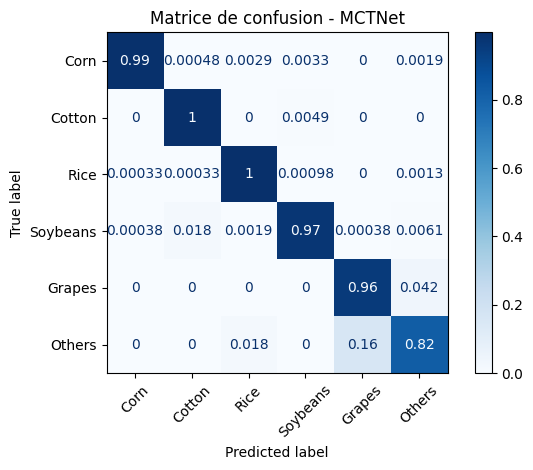


Classification Report :

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      2103
           1       0.89      1.00      0.94       412
           2       0.99      1.00      1.00      3067
           3       1.00      0.97      0.98      2615
           4       0.77      0.96      0.86       306
           5       0.92      0.82      0.87       542

    accuracy                           0.98      9045
   macro avg       0.93      0.96      0.94      9045
weighted avg       0.98      0.98      0.98      9045


OA: 0.977 | Kappa: 0.969 | F1: 0.940


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
class_names = [CLASS_NAMES[code] for code in label_encoder.classes_]

# get predictions
y_pred = model.predict((X_test, mask_test)).argmax(axis=1)


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matrice de confusion - MCTNet")
plt.tight_layout()
plt.show()

# Precision / Recall / F1
print("\nClassification Report :\n")
print(classification_report(y_test, y_pred))

# OA / Kappa / F1
from sklearn.metrics import cohen_kappa_score, f1_score
oa    = np.mean(y_pred == y_test)
kappa = cohen_kappa_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred, average='macro')
print(f"\nOA: {oa:.3f} | Kappa: {kappa:.3f} | F1: {f1:.3f}")

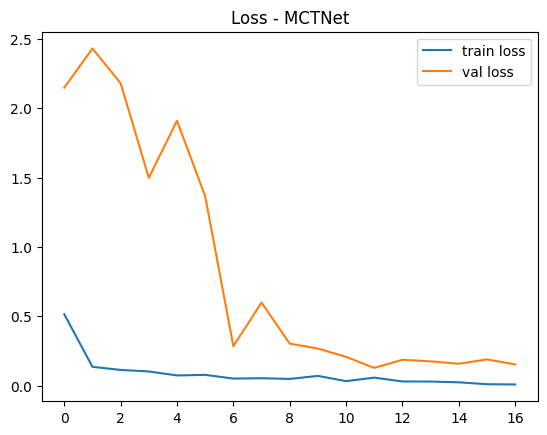

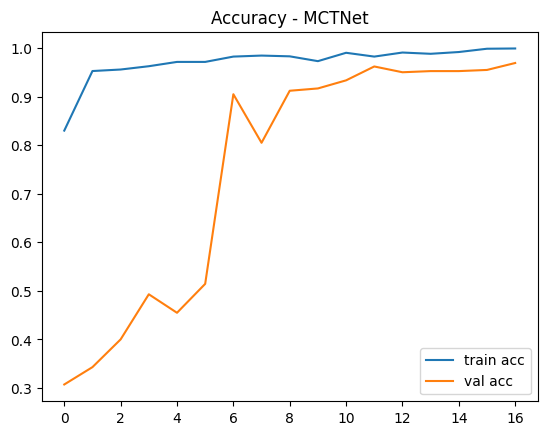

In [ ]:
# Learning plots
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss - MCTNet")
plt.show()

plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy - MCTNet")
plt.show()

[8, 9, 0, 1, 2, 3, 4, 5, 6, 7]
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step


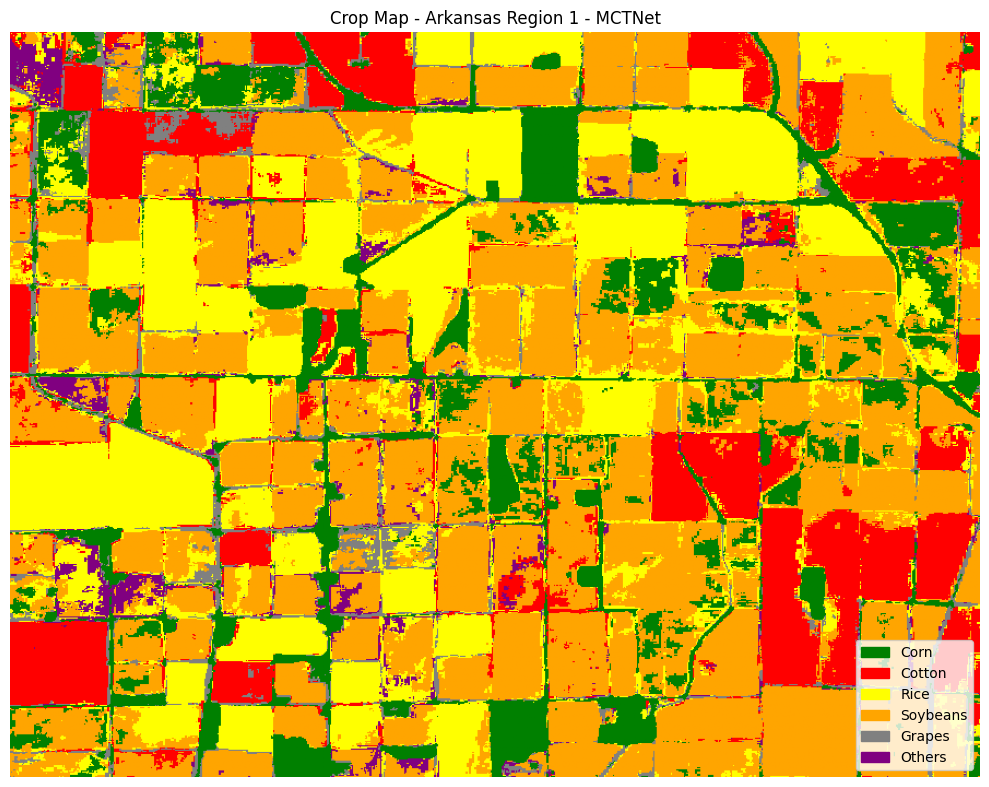

1216/1216 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step


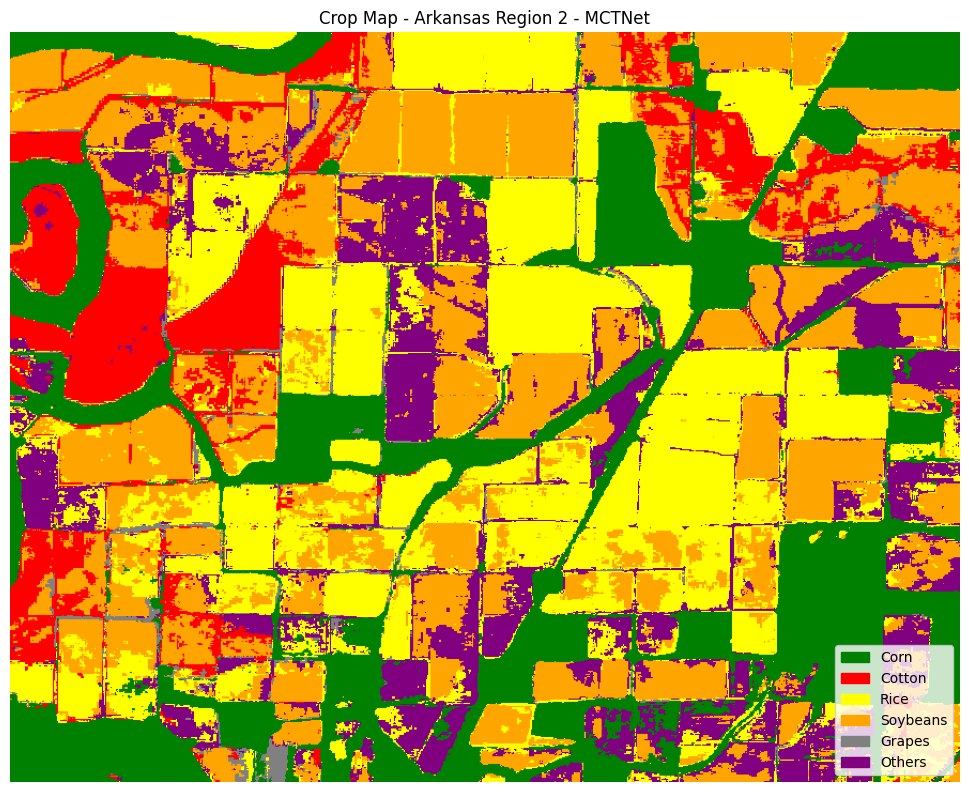

1173/1173 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step


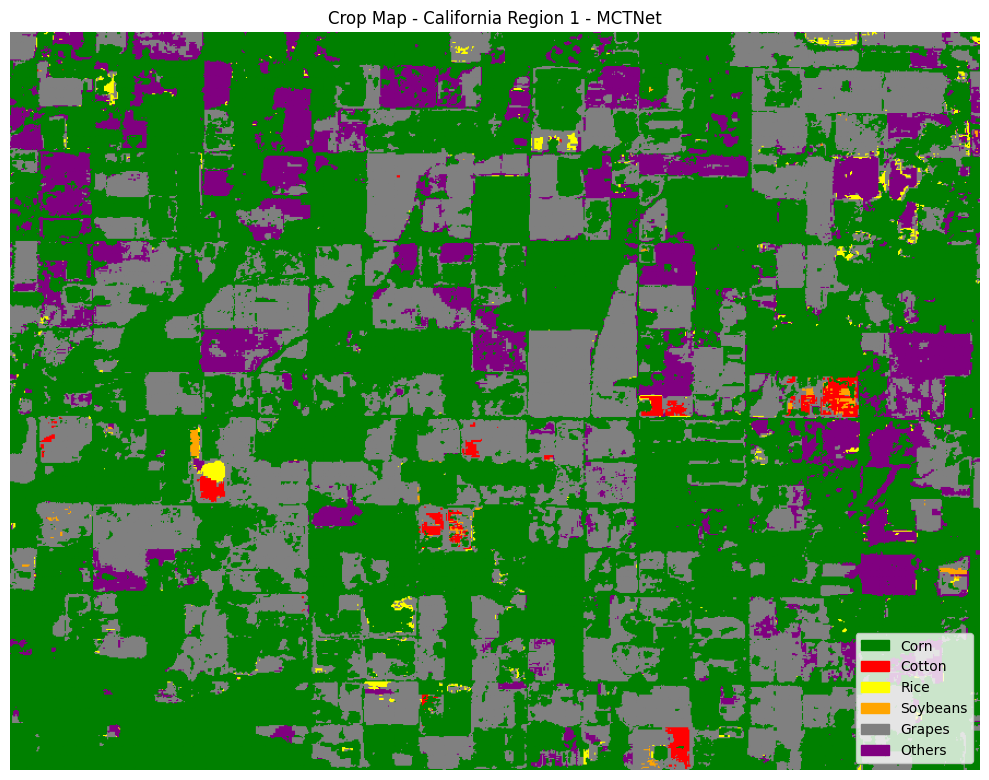

1126/1126 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step


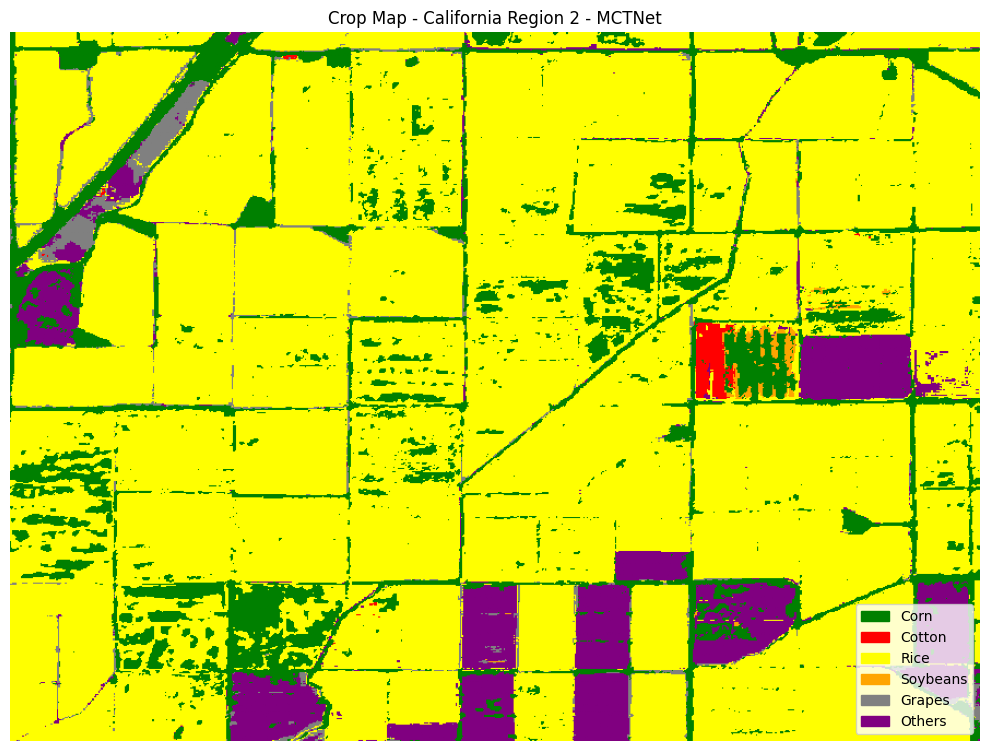

In [ ]:
# this code jsut visualizes how the classification show up as an image
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

raster_order = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']
train_order  = ['B11','B12','B2','B3','B4','B5','B6','B7','B8','B8A']
reorder_idx = [raster_order.index(b) for b in train_order]
print(reorder_idx)
colors = ['green', 'red', 'yellow', 'orange', 'gray', 'purple']
cmap = ListedColormap(colors[:len(class_names)])
legend = [Patch(color=colors[i], label=class_names[i]) for i in range(len(class_names))]


def generate_crop_map(raster_path, title):
    # load raster
    with rasterio.open(raster_path) as file:
        data = file.read()
        transform = file.transform

    H, W = data.shape[1], data.shape[2]

    data = data.reshape(36, 10, H, W)  # (36, 10, H, W)
    data = data[:, reorder_idx, :, :]  # reorders bands (raster and .csv dont share the same order)
    data = data.transpose(2, 3, 0, 1)  # (H, W, 36, 10)
    X_map = data.reshape(-1, 36, 10).astype(np.float32)

    mask_map = (X_map.sum(axis=-1) != 0).astype(np.float32)

    # model prediction
    y_map = model.predict((X_map, mask_map), batch_size=512, verbose=1).argmax(axis=1)
    y_map = y_map.reshape(H, W)

    # plotting
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(y_map, cmap=cmap, vmin=0, vmax=len(class_names)-1)
    ax.legend(handles=legend, loc='lower right')
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# Arkansas Region 1
generate_crop_map(
    os.path.join(data_path, "arkansas", "region1", "SentinelTimeSeries_2021_ArkansasRegion1.tif"),
    "Crop Map - Arkansas Region 1 - MCTNet",
)

# Arkansas Region 2
generate_crop_map(
    os.path.join(data_path, "arkansas", "region2", "SentinelTimeSeries_2021_ArkansasRegion2.tif"),
    "Crop Map - Arkansas Region 2 - MCTNet",
)

# California Region 1
generate_crop_map(
    os.path.join(data_path, "california", "region1", "SentinelTimeSeries_2021_CaliforniaRegion1.tif"),
    "Crop Map - California Region 1 - MCTNet",
)

# California Region 2
generate_crop_map(
    os.path.join(data_path, "california", "region2", "SentinelTimeSeries_2021_CaliforniaRegion2.tif"),
    "Crop Map - California Region 2 - MCTNet",
)

# Model Saving
the best part

In [ ]:
model.save(os.path.join("drive", "MyDrive", "AARN_Projet", "Models", 'MCTNet_V1.keras'))